# Koopman Operator Training with Autoencoder

This notebook implements a training pipeline for a Koopman operator model combined with an autoencoder. The code includes data loading, model definition, training, and visualization of results such as trajectories and eigenvalues.


In [1]:
import os
# Move up one directory to make sure the script can find the modules and save files in the correct place
os.chdir('..')
# Verify the current working directory
print(os.getcwd())

import argparse
import json
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader, Dataset
import torch.nn.init as init
import torch.multiprocessing as mp

# Import local modules (assuming these are available in your environment)
from utils.tools import set_seed, get_device
from utils.config_args import get_args
from utils.Viz import *
from KoopmanTrainer import Trainer
from data_handler import KoopmanDataHandler
from models.autoencoder import AutoEncoder
from models.koopman_operator import Knet

# Set multiprocessing start method
try:
    mp.set_start_method('spawn')
except RuntimeError:
    pass  # method already set

# Disable deterministic algorithms for flexibility
torch.use_deterministic_algorithms(False)


/Users/mohammedahmed/Desktop/Project/KoopKAN/Testing Multiple Repos/bio-koopman-autoencoder


## Training Settings

Configure the training settings, including random seeds for reproducibility and device selection (CUDA or CPU).

In [2]:
# Get arguments (assuming get_args() handles command-line or default args)
args = get_args()

# Set seeds for reproducibility
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.cuda.manual_seed(args.seed)
torch.manual_seed(args.seed)
np.random.seed(args.seed)
set_seed(args.seed)

# Device configuration
device = get_device()

Using the CPU


In [3]:
# editing the args 
# in this experiement we increased the timesteps to 201 and the time to 40 which is double the original experiment to make sure we would capture the limit cycle 
args.dataset = 'isolated_repressilator'
args.folder = 'isolated_repressilator_200_time_steps_64_bottleneck_higher_sampling'
args.time_steps = 201
args.prediction_length = 200
args.max_time = 20
args.num_samples = 15000
args.bottleneck = 64
args.decoder_loss_weight = 10
args.lr = 1e-3
args.epochs = 300
args.loss_function = 'mse'
args.unitary_loss_weight = 10


## Create Experiment Folder

Set up the folder structure to save experiment results, including arguments in a JSON file.

In [4]:
# Create experiment folder
experiment_folder = 'experiments'
if not os.path.isdir(experiment_folder):
    os.mkdir(experiment_folder)

folder_path = os.path.join(experiment_folder, args.folder)
os.makedirs(folder_path, exist_ok=True)

# Save arguments to JSON
args_dict = vars(args)
with open(os.path.join(folder_path, 'args.json'), 'w') as f:
    json.dump(args_dict, f,indent=2)

## Load and Prepare Dataset

Load and preprocess the dataset using the `KoopmanDataHandler` class, then create data loaders for training, validation, and testing.

In [5]:
# Convert args to a dictionary for the data handler

config = {
    "dataset": args.dataset,
    "data_dir": args.data_dir,
    "train_size": args.train_size,
    "val_size": args.val_size,
    "batch_size": args.batch_size,
    "noise": args.noise,
    "orthogonal_projection": args.orthogonal_projection,
    "num_combinations": args.num_combinations,
    "num_samples": args.num_samples,
    "time_steps": args.time_steps,
    "max_time": args.max_time,
    "normalize": args.normalize,
    "prediction_length": args.prediction_length,
    "stride": args.stride,
    "device": device,
    "theta": args.theta
}

# Initialize data handler
data_handler = KoopmanDataHandler(config)
data_handler.load_data()
preprocessed_data = data_handler.preprocess()
dataloaders = data_handler.create_dataloaders()

train_loader = dataloaders["train"]
val_loader = dataloaders["val"]
test_loader = dataloaders["test"]

# Get data dimensions for model initialization
input_size = preprocessed_data['Xtrain'].shape[-1]

Generating data...


100%|██████████| 15000/15000 [00:00<00:00, 42967.76it/s]
/Users/mohammedahmed/Desktop/Project/KoopKAN/Testing Multiple Repos/bio-koopman-autoencoder/data_handler.py:130: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  Xtrain = torch.tensor(Xtrain, dtype=torch.float32).to(self.device)
/Users/mohammedahmed/Desktop/Project/KoopKAN/Testing Multiple Repos/bio-koopman-autoencoder/data_handler.py:131: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  Xval = torch.tensor(Xval, dtype=torch.float32).to(self.device)
/Users/mohammedahmed/Desktop/Project/KoopKAN/Testing Multiple Repos/bio-koopman-autoencoder/data_handler.py:132: UserWarning: To copy construct from a tensor, it is recommended to use sourceT

the shape of the data is torch.Size([15000, 201, 6])
Processing dataset: isolated_repressilator
train_idx: 12000, val_idx: 13500
Processed data shapes - Train: torch.Size([12000, 201, 6]), Val: torch.Size([1500, 201, 6]), Test: torch.Size([1500, 201, 6])


## Model Definition

Define the autoencoder (`AutoEncoder`) and Koopman operator (`Knet`), then combine them into a `ModuleDict`.

In [6]:
# Model definition
ae = AutoEncoder(
    input_size=input_size,
    encoded_size=args.bottleneck,
    encoder_hidden_layers=args.encoder_hidden_layers,
    decoder_hidden_layers=args.decoder_hidden_layers,
    network_type=args.network_type,
    batch_norm=False
)
knet = Knet(size=args.bottleneck)

# Combine AE and Knet as a ModuleDict
model = torch.nn.ModuleDict({'ae': ae, 'knet': knet})
model = model.to(device)

## Model Summary

Display the total number of parameters and the model architecture.

In [7]:
print('**** Setup ****')
print('Total params: %.2fM' % (sum(p.numel() for p in model.parameters())/1000000.0))
print('Total params: %.2fk' % (sum(p.numel() for p in model.parameters())/1000.0))
print('************')

print('**** Model Architecture ****')
print(model)
print('***************************')

**** Setup ****
Total params: 0.04M
Total params: 38.57k
************
**** Model Architecture ****
ModuleDict(
  (ae): AutoEncoder(
    (encoder): Sequential(
      (0): MLP(
        (net): ModuleList(
          (0): Linear(in_features=6, out_features=100, bias=True)
          (1): LeakyReLU(negative_slope=0.01)
          (2): Linear(in_features=100, out_features=100, bias=True)
          (3): LeakyReLU(negative_slope=0.01)
          (4): Linear(in_features=100, out_features=64, bias=True)
        )
      )
      (1): Dropout(p=0.3, inplace=False)
    )
    (decoder): MLP(
      (net): ModuleList(
        (0): Linear(in_features=64, out_features=100, bias=True)
        (1): LeakyReLU(negative_slope=0.01)
        (2): Linear(in_features=100, out_features=100, bias=True)
        (3): LeakyReLU(negative_slope=0.01)
        (4): Linear(in_features=100, out_features=6, bias=True)
      )
    )
  )
  (knet): Knet(
    (net): Linear(in_features=64, out_features=64, bias=False)
  )
)
*********

## Load from Checkpoint

Optionally load a pre-trained model from a checkpoint if specified.

In [8]:
if args.load_from_checkpoint:
    checkpoint_path = os.path.join(folder_path, 'model.pkl')
    if os.path.isfile(checkpoint_path):
        model.load_state_dict(torch.load(checkpoint_path))
        print(f'Model loaded from {checkpoint_path}')
    else:
        print(f'No checkpoint found at {checkpoint_path}')

## Training

Train the model using the `Trainer` class with the specified data loaders.

In [9]:
trainer = Trainer(model, args, device, do_eval=True, train_loader=train_loader, val_loader=val_loader)

Using the CPU


In [10]:
trainer.train_KoopmanAE()

Training Epochs:   7%|▋         | 20/300 [05:44<1:24:04, 18.02s/it]

Epoch 20/300
Training - Recon Loss: 9.000285e-05, Linear Loss: 3.013764e-04, Pred Loss: 5.818406e-04, Unitary Loss: 4.759181e-05, Total Loss: 7.495729e-03
Validation - Recon Loss: 4.051633e-05, Linear Loss: 2.230148e-04, Pred Loss: 4.492012e-04,Unitary Loss: 4.626414e-05, Total Loss: 5.120190e-03


Training Epochs:  13%|█▎        | 40/300 [11:39<1:15:34, 17.44s/it]

Epoch 40/300
Training - Recon Loss: 8.156100e-05, Linear Loss: 2.444885e-04, Pred Loss: 3.811561e-04, Unitary Loss: 3.781420e-05, Total Loss: 5.249801e-03
Validation - Recon Loss: 4.276531e-05, Linear Loss: 1.474388e-04, Pred Loss: 2.437848e-04,Unitary Loss: 4.116284e-05, Total Loss: 3.012940e-03


Training Epochs:  20%|██        | 60/300 [17:02<58:56, 14.74s/it]  

...

Training Epochs:  93%|█████████▎| 280/300 [1:23:36<05:56, 17.84s/it]

Epoch 280/300
Training - Recon Loss: 3.582261e-05, Linear Loss: 1.002023e-04, Pred Loss: 1.282277e-04, Unitary Loss: 1.672470e-05, Total Loss: 1.907952e-03
Validation - Recon Loss: 1.839136e-05, Linear Loss: 6.357525e-05, Pred Loss: 6.969175e-05,Unitary Loss: 1.683012e-05, Total Loss: 9.444063e-04


Training Epochs: 100%|██████████| 300/300 [1:29:50<00:00, 17.97s/it]

Epoch 300/300
Training - Recon Loss: 3.590386e-05, Linear Loss: 9.752183e-05, Pred Loss: 1.341400e-04, Unitary Loss: 1.716680e-05, Total Loss: 1.969628e-03
Validation - Recon Loss: 1.747808e-05, Linear Loss: 5.737811e-05, Pred Loss: 9.205611e-05,Unitary Loss: 1.565957e-05, Total Loss: 1.152720e-03


(ModuleDict(
   (ae): AutoEncoder(
     (encoder): Sequential(
       (0): MLP(
         (net): ModuleList(
           (0): Linear(in_features=6, out_features=100, bias=True)
           (1): LeakyReLU(negative_slope=0.01)
           (2): Linear(in_features=100, out_features=100, bias=True)
           (3): LeakyReLU(negative_slope=0.01)
           (4): Linear(in_features=100, out_features=64, bias=True)
         )
       )
       (1): Dropout(p=0.3, inplace=False)
     )
     (decoder): MLP(
       (net): ModuleList(
         (0): Linear(in_features=64, out_features=100, bias=True)
         (1): LeakyReLU(negative_slope=0.01)
         (2): Linear(in_features=100, out_features=100, bias=True)
         (3): LeakyReLU(negative_slope=0.01)
         (4): Linear(in_features=100, out_features=6, bias=True)
       )
     )
   )
   (knet): Knet(
     (net): Linear(in_features=64, out_features=64, bias=False)
   )
 ),
 AdamW (
 Parameter Group 0
     amsgrad: False
     betas: (0.9, 0.999)
     c

In [11]:

trainer.test_KoopmanAE(test_loader)

Test - Recon Loss: 1.880918e-05, Linear Loss: 6.137397e-05, Pred Loss: 8.975030e-05, Total Loss: 1.146969e-03


## Visualization

Visualize the original, reconstructed, and predicted trajectories from the test set.

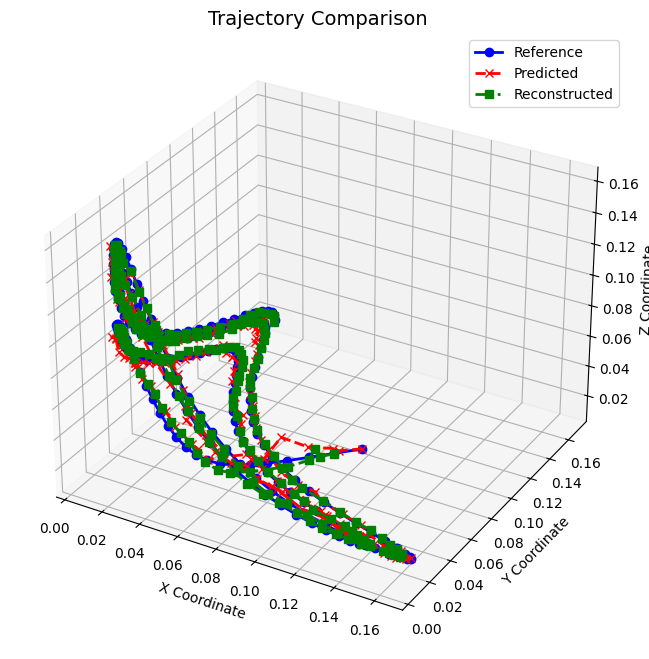

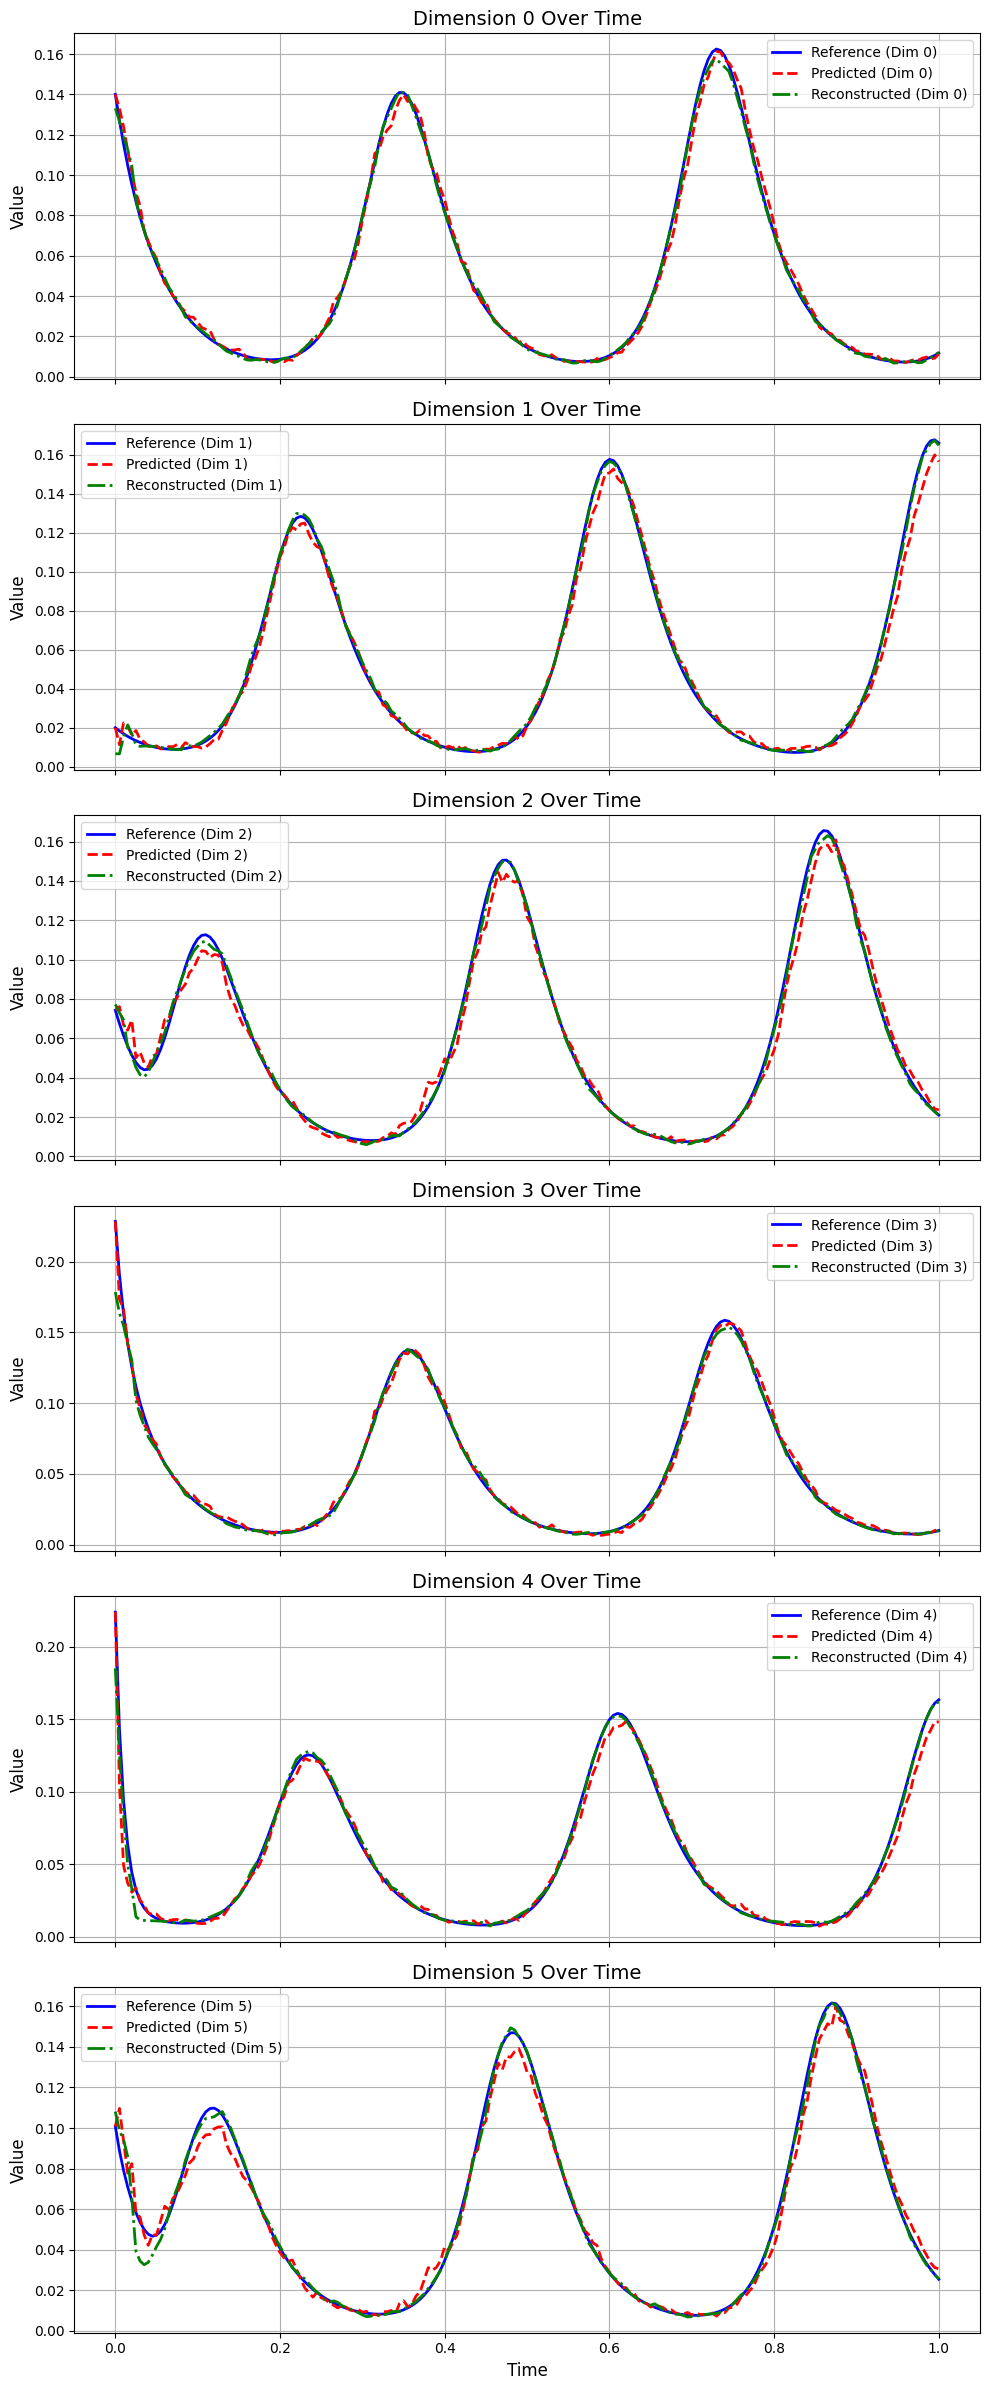

In [12]:
# for saving the results first

# Get a test sample
traj = preprocessed_data["Xtest"][5].to(device)

# Get reconstructed trajectory
model.eval()
with torch.no_grad():
    Y, reconstructed_traj = model.ae(traj)


# Get predicted trajectory
predicted_traj = trainer.predict_new(X0=traj[0], steps=len(traj)-1)

# Convert to numpy for plotting
traj = traj.cpu().detach().numpy()
reconstructed_traj = reconstructed_traj.cpu().detach().numpy()
predicted_traj = predicted_traj.cpu().detach().numpy()

# Plot trajectories
plot_trajectories(traj[:,:3], predicted_traj[:,:3], reconstructed_traj[:,:3], folder_path=folder_path,save=True)
plot_trajectory_comparison(traj, predicted_traj, reconstructed_traj, folder_path=folder_path,save=True)

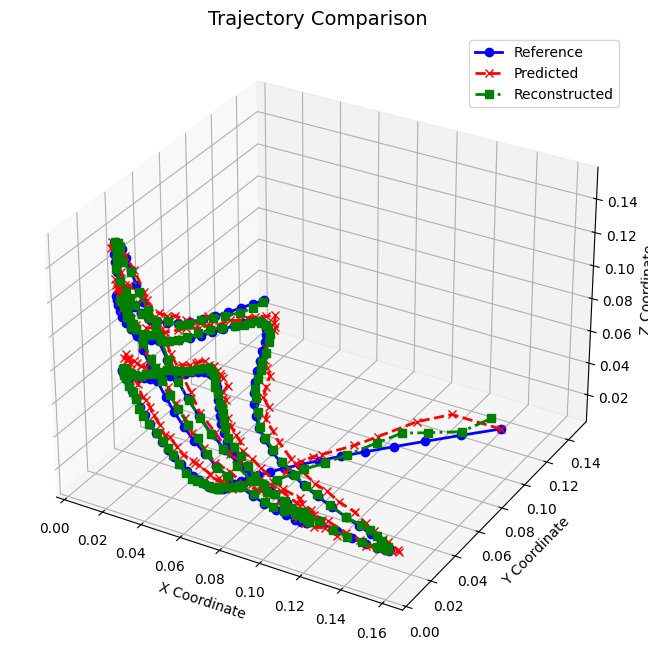

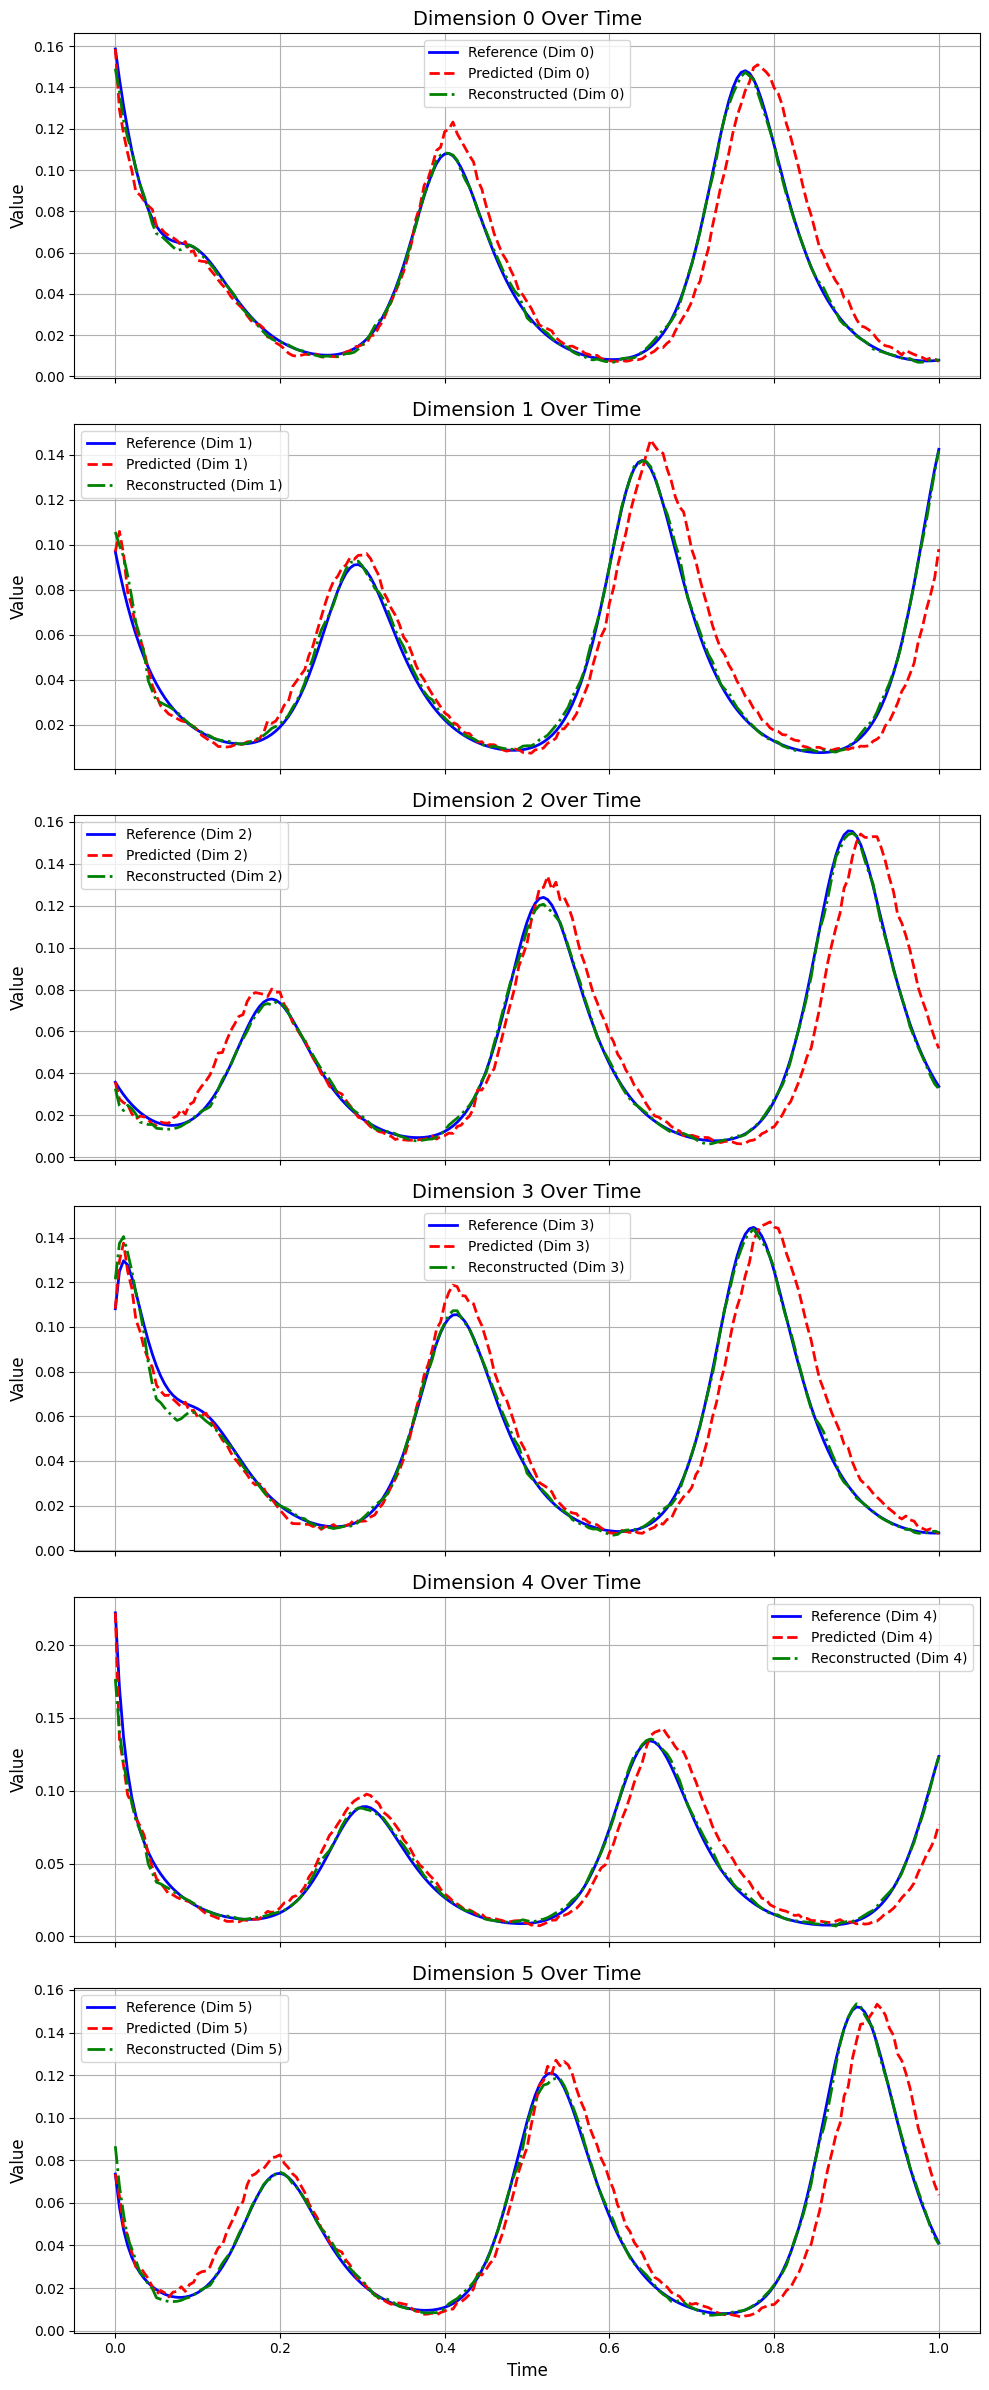

In [13]:
# Get a test sample
traj = preprocessed_data["Xtest"][3].to(device)

# Get reconstructed trajectory
model.eval()
with torch.no_grad():
    Y, reconstructed_traj = model.ae(traj)


# Get predicted trajectory
predicted_traj = trainer.predict_new(X0=traj[0], steps=len(traj)-1)

# Convert to numpy for plotting
traj = traj.cpu().detach().numpy()
reconstructed_traj = reconstructed_traj.cpu().detach().numpy()
predicted_traj = predicted_traj.cpu().detach().numpy()

# Plot trajectories
plot_trajectories(traj[:,:3], predicted_traj[:,:3], reconstructed_traj[:,:3], folder_path=folder_path,save=False)
plot_trajectory_comparison(traj, predicted_traj, reconstructed_traj, folder_path=folder_path,save=False)

## Eigenvalues Visualization

Compute and visualize the eigenvalues of the Koopman operator on a unit circle.

Eigenvalues:
[ 1.0010929 -0.08188859j  1.0010929 +0.08188859j  0.9938247 +0.01944565j
  0.9938247 -0.01944565j  0.9875219 +0.j          0.9750156 -0.1572809j
  0.9750156 +0.1572809j   0.96196806-0.23847671j  0.96196806+0.23847671j
  0.89299625-0.4398079j   0.89299625+0.4398079j   0.8008124 -0.594806j
  0.8008124 +0.594806j    0.77289224-0.6310208j   0.77289224+0.6310208j
  0.72593427+0.6845343j   0.72593427-0.6845343j   0.6360407 -0.7689082j
  0.6360407 +0.7689082j   0.5721855 -0.8181486j   0.5721855 +0.8181486j
  0.49512827-0.8672077j   0.49512827+0.8672077j   0.37689975-0.92446667j
  0.37689975+0.92446667j  0.26315713-0.96288085j  0.26315713+0.96288085j
  0.05335743-0.9971951j   0.05335743+0.9971951j  -0.00731104-0.9986296j
 -0.00731104+0.9986296j  -0.13204494+0.98915195j -0.13204494-0.98915195j
 -0.18862209-0.980502j   -0.18862209+0.980502j   -0.24312615-0.9683763j
 -0.24312615+0.9683763j  -0.37531927-0.925215j   -0.37531927+0.925215j
 -0.4937476 -0.86807895j -0.4937476 +0.86807895j

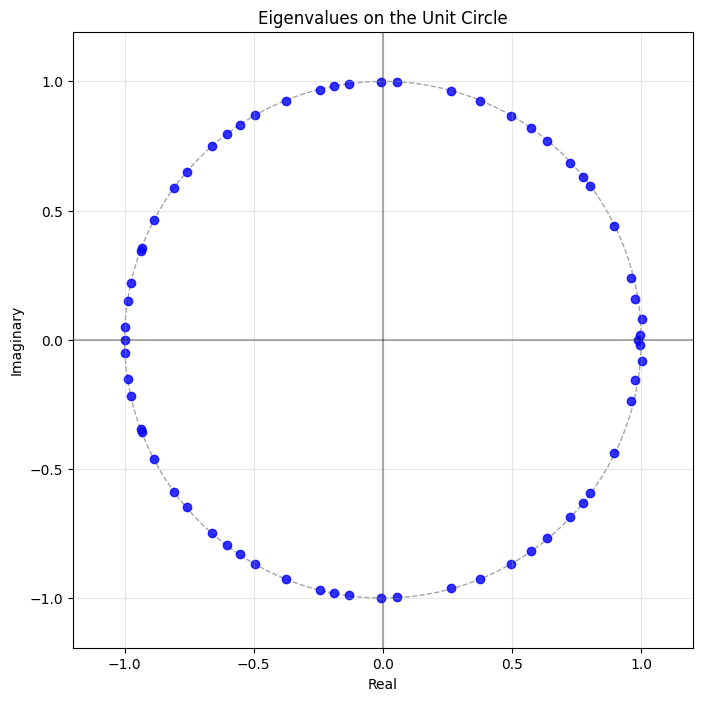

In [14]:
# Compute eigenvalues
eigenvalues, eigenvectors = torch.linalg.eig(model.knet.net.weight)
eigenvalues = eigenvalues.cpu().detach().numpy()
idx = np.argsort(eigenvalues.real)[::-1]
eigenvalues = eigenvalues[idx]

# Print eigenvalues
print('Eigenvalues:')
print(eigenvalues)

# Plot eigenvalues on unit circle
plot_eigenvalues_on_unit_circle(eigenvalues, folder_path)

print(f"Training and evaluation completed. Results saved in {folder_path}")

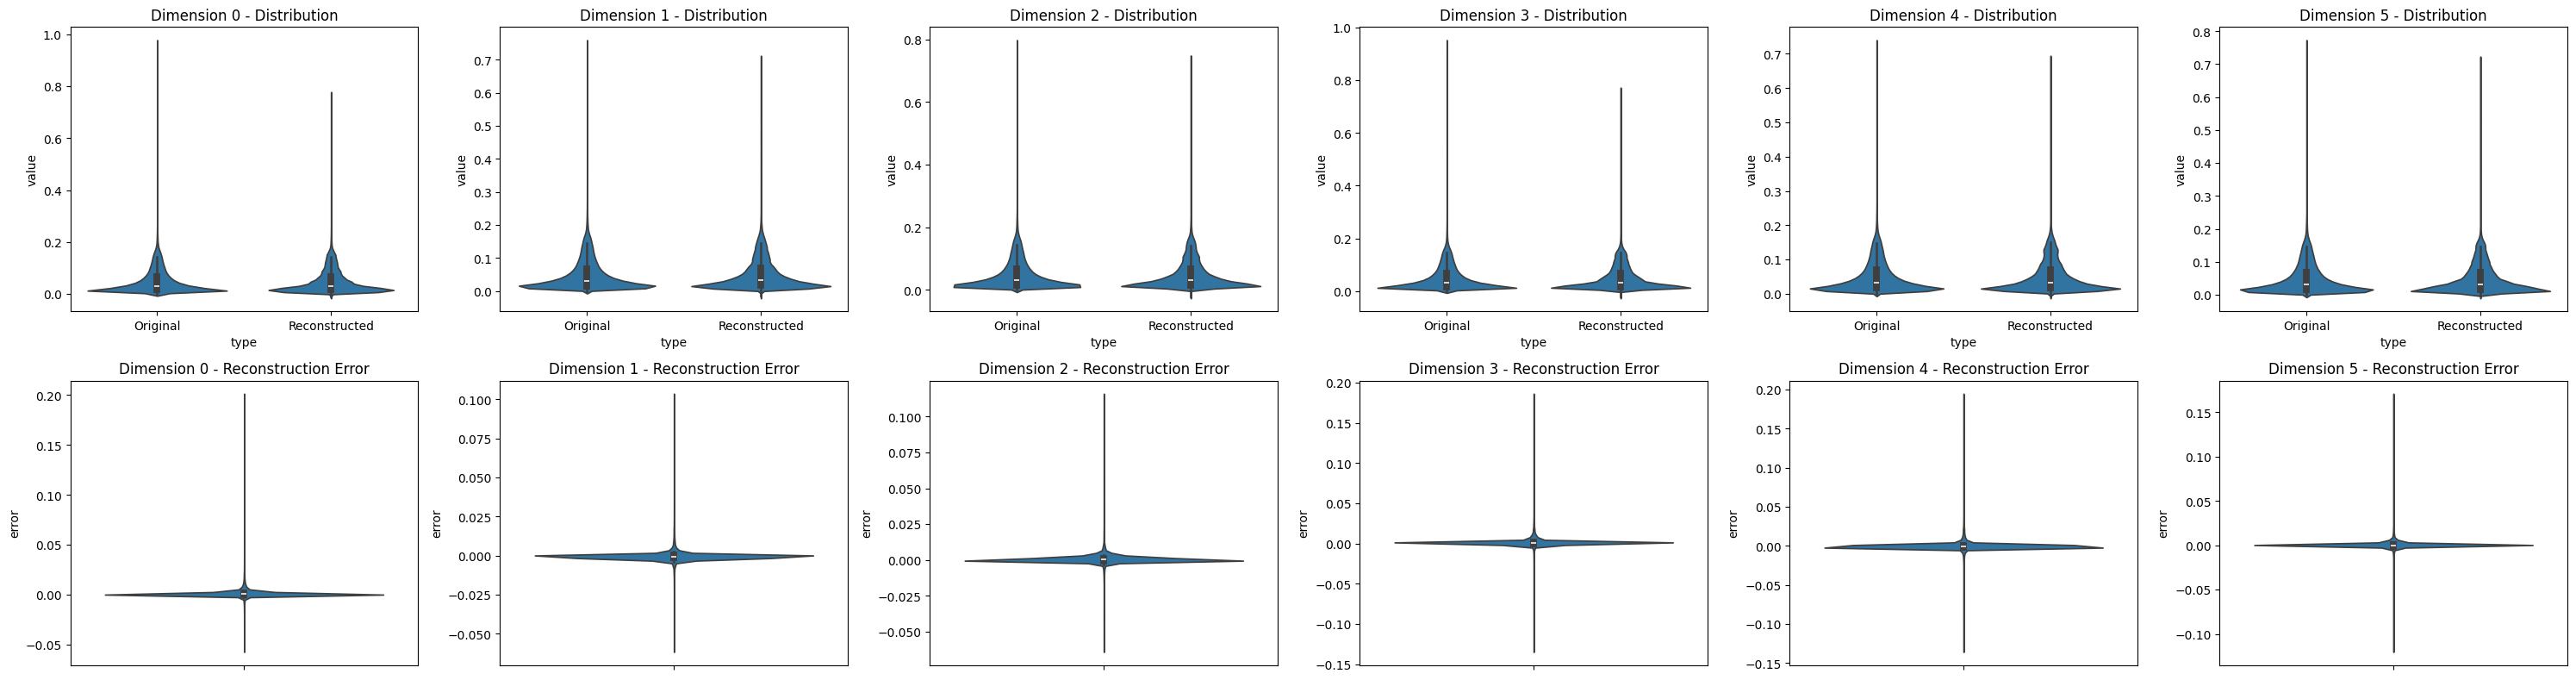

In [15]:
violin_plot(model, preprocessed_data["Xtest"], device, folder_path)

### Long Term Prediction on the Repressilator

In [1]:
from utils.data_loader import RepressilatorModel

#y = [15, 20, 80,  90, 30, 70]
y = np.random.rand(6) * 100
#y = y = [70, 10, 3,  65, 12, 3]
print('Initial conditions:', y)
Repressilator_model = RepressilatorModel(y0=y)

parameters = Repressilator_model.suggested_parameters()
times =  np.linspace(0,100, 1001)
traj = Repressilator_model.simulate(parameters, times)

traj = traj/data_handler.Xscale


ModuleNotFoundError: No module named 'utils'

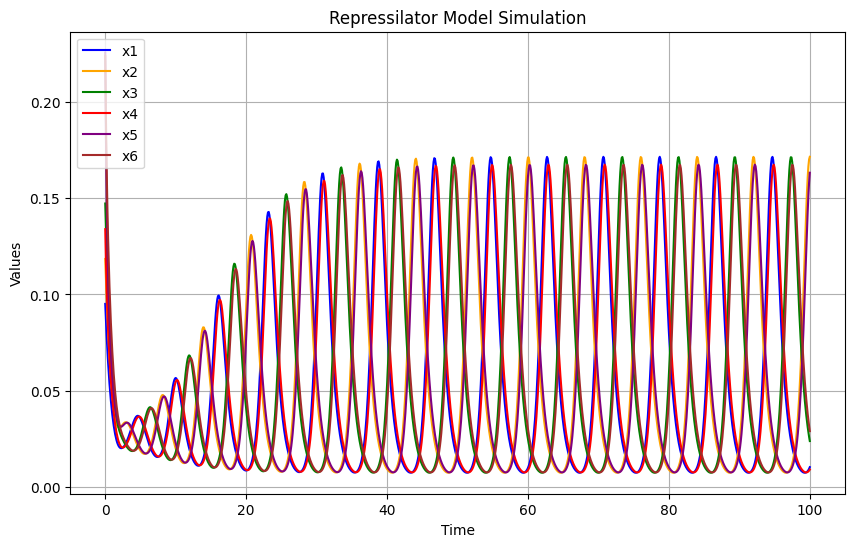

In [119]:
# visualize each dimension 

plt.figure(figsize=(10, 6))
plt.plot(times, traj[:, 0], label='x1', color='blue')
plt.plot(times, traj[:, 1], label='x2', color='orange')
plt.plot(times, traj[:, 2], label='x3', color='green')
plt.plot(times, traj[:, 3], label='x4', color='red')
plt.plot(times, traj[:, 4], label='x5', color='purple')
plt.plot(times, traj[:, 5], label='x6', color='brown')
plt.xlabel('Time')
plt.ylabel('Values')
plt.title('Repressilator Model Simulation')
plt.legend()
plt.grid()
plt.show()

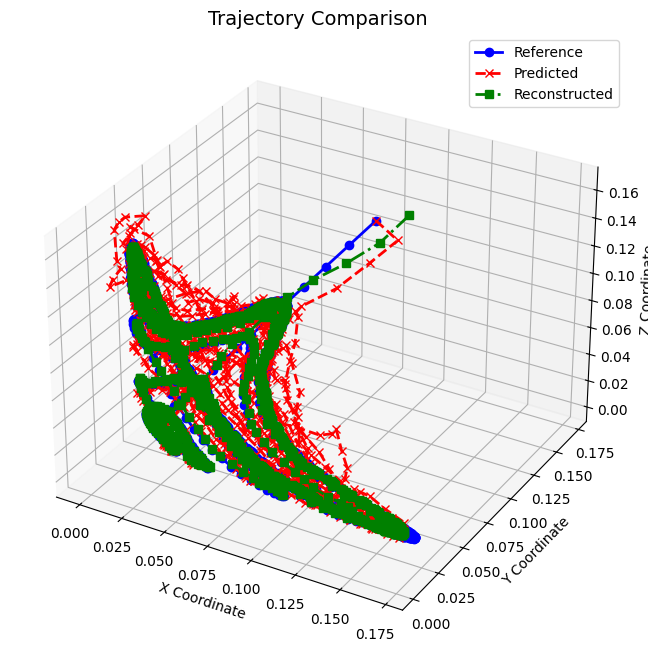

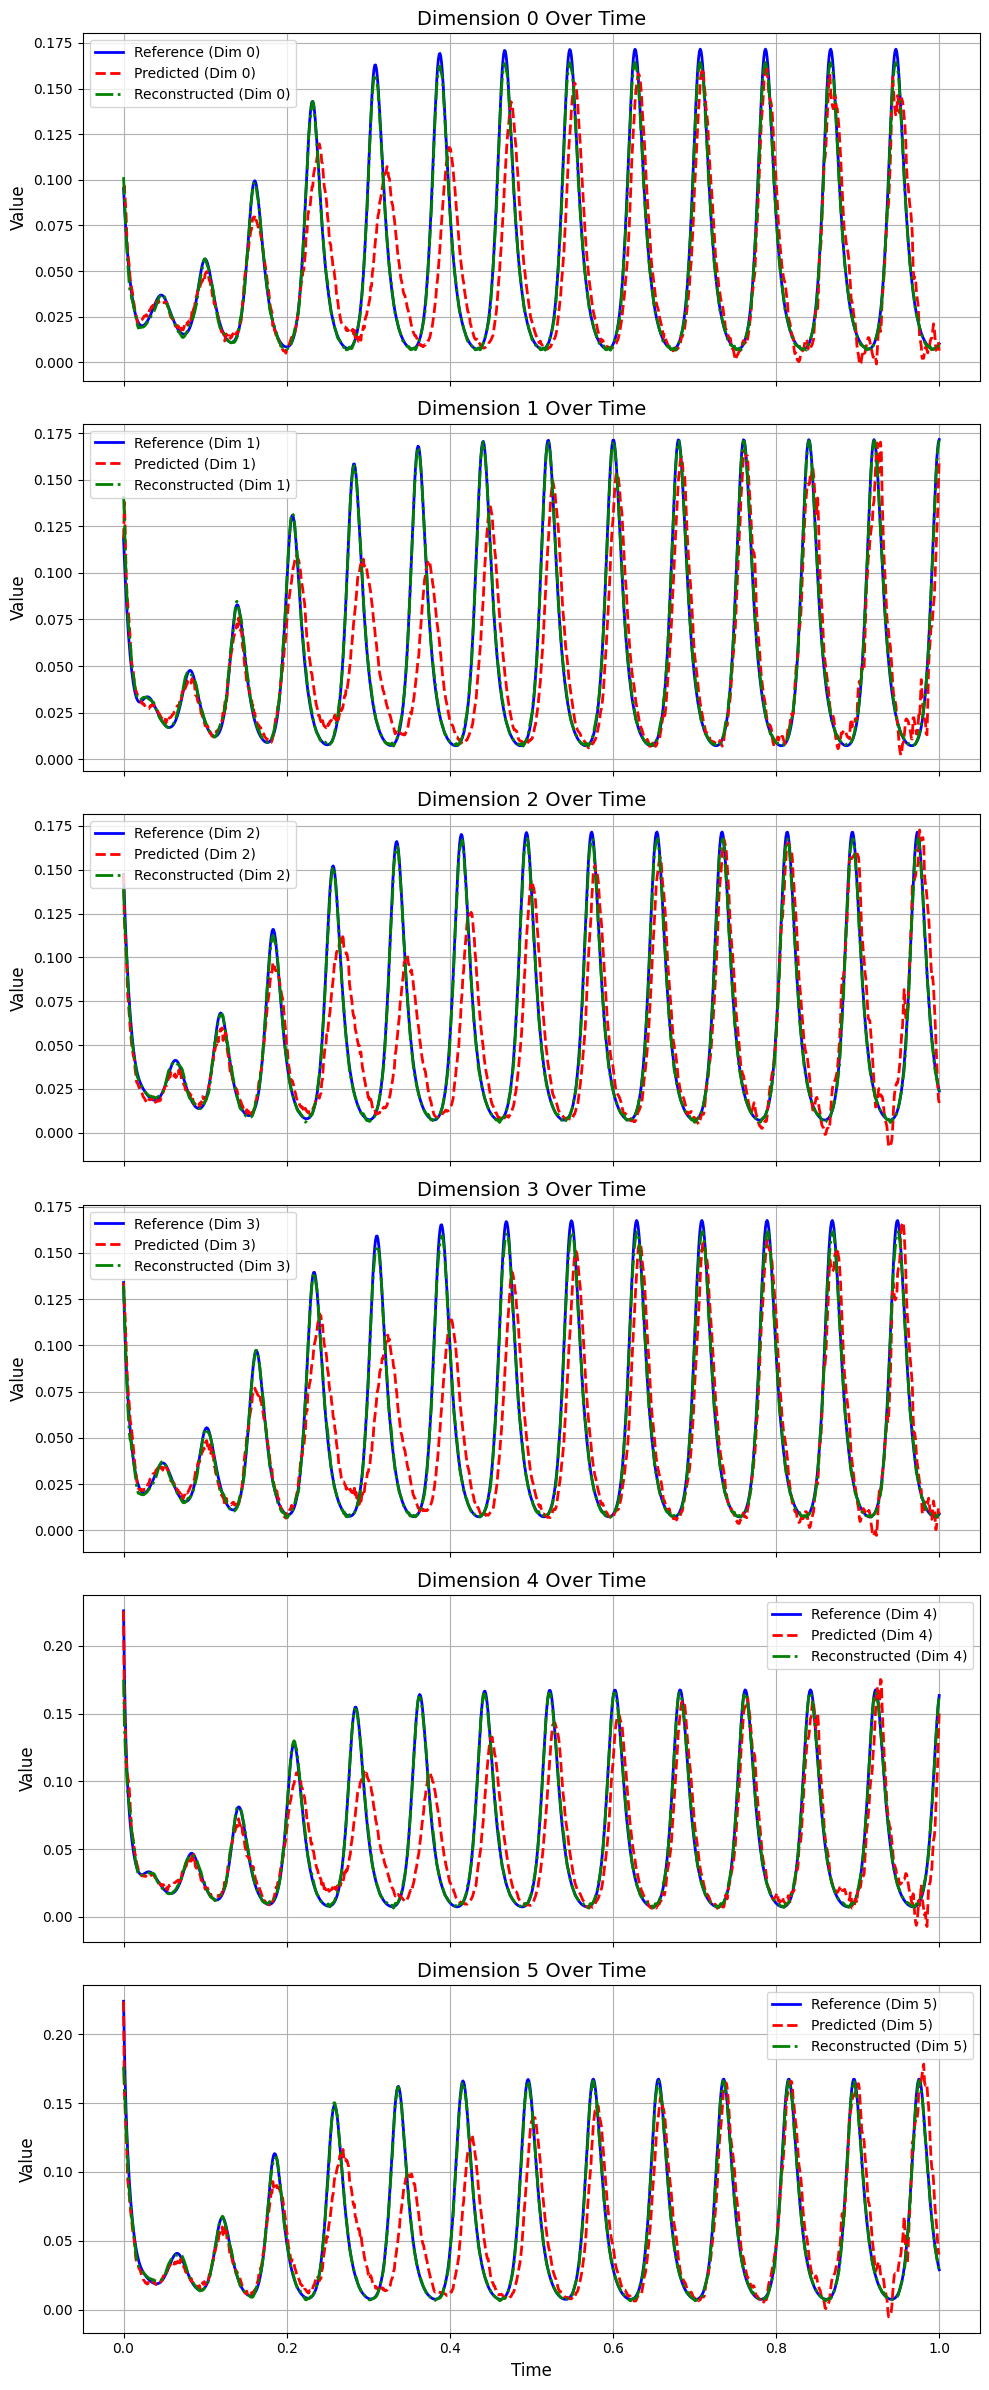

In [120]:
# traj as tensor
traj = torch.tensor(traj, dtype=torch.float32).to(device)

# Get reconstructed trajectory
model.eval()
with torch.no_grad():
    Y, reconstructed_traj = model.ae(traj)


# Get predicted trajectory
predicted_traj = trainer.predict_new(X0=traj[0], steps=len(traj)-1)

# Convert to numpy for plotting
traj = traj.cpu().detach().numpy()
reconstructed_traj = reconstructed_traj.cpu().detach().numpy()
predicted_traj = predicted_traj.cpu().detach().numpy()

# Plot trajectories
plot_trajectories(traj[:,:3], predicted_traj[:,:3], reconstructed_traj[:,:3], folder_path=folder_path,save=False)
plot_trajectory_comparison(traj, predicted_traj, reconstructed_traj, folder_path=folder_path,save=False)
